# Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [3]:
# check missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [4]:
# check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


### All columns have correct data types and no missing values, so the dataset is structurally fine and ready for analysis.

In [5]:
# summary statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Everything looks structurally fine with realistic ranges.

In [6]:
# check duplicate rows
print(df.duplicated().sum())

0


### The dataset has no duplicate values.

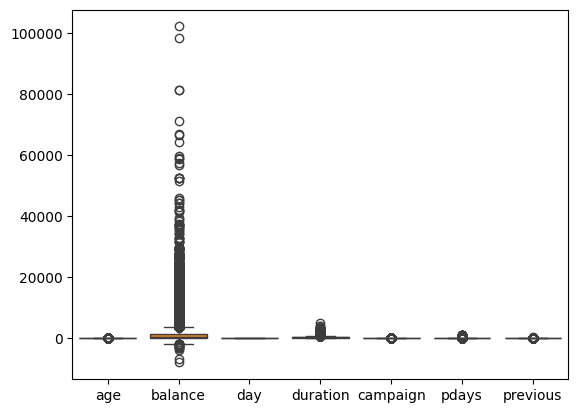

In [7]:
# select numeric colunms
num_cols = ['age','balance','day','duration','campaign','pdays','previous']

# create a boxplot for each column
sns.boxplot(data=df[num_cols])
plt.show()

### The dataset shows extreme but domain-valid variation in balance reflecting real-world wealth inequality, while all other variables are clean with no significant outliers.

In [8]:
# select categorical column
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome','y']

# unique values
for col in cat_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'job': <StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str
Unique values in 'marital': <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
Unique values in 'education': <StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str
Unique values in 'default': <StringArray>
['no', 'yes']
Length: 2, dtype: str
Unique values in 'housing': <StringArray>
['yes', 'no']
Length: 2, dtype: str
Unique values in 'loan': <StringArray>
['no', 'yes']
Length: 2, dtype: str
Unique values in 'contact': <StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str
Unique values in 'month': <StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str
Unique values in 'poutcome': <StringArr

In [9]:
# standardize column, remove dot for consistency
df['job'] = df['job'].str.replace('.', '', regex=False)

In [10]:
# define the correct order
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order,ordered=True)

In [11]:
import os

# save clean dataset
df.to_csv('../data/processed/bank-full-clean.csv', index=False)